# Punto 1
se genera un conjunto de datos sintetico entre 1 y 20 clusteres distribuidos aleatoriamente en un rango amplio. Se visualiza sin diferenciar los clusteres ni mostrar los centroides

In [2]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# definir el numero de centroides (entre 1 y 20)
num_centroids = np.random.randint(1, 21)
print('Numero de centroides: ', num_centroids)

# generar coordenadas de los centroides con una separacion significativa
blob_centers = np.random.uniform(-10, 10, size=(num_centroids, 2))

# definir la dispercion uniforme para los grupos
blob_std = np.full(num_centroids, 1.2)

# generar los datos de los grupos
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

Numero de centroides:  19


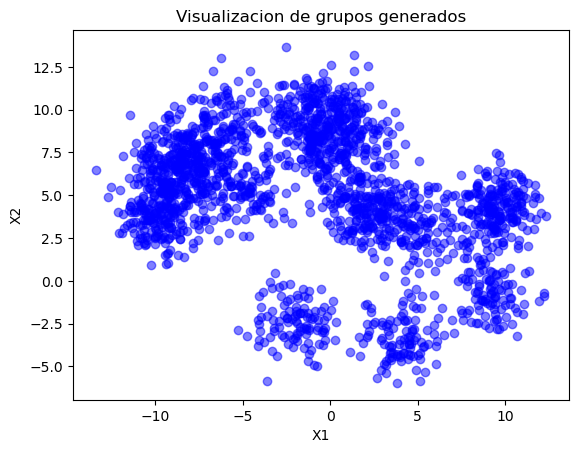

In [4]:
# visualizacion con todos los puntos dek mismo color y sin los centroides
plt.scatter(X[:, 0], X[:, 1], color='blue', alpha=0.5)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Visualizacion de grupos generados')
plt.show()

**Metodo del Codo**

**Evaluacion de diferentes valires de K (clusters):**

* Se ejecuta K-Means para vlores entre 2 y 20 y se guarda la inercia (suma de las distancias al centro del cluster)

**Metodo del Codo geometrico**

* Se tima la linea recta entre los extremos (k=2 y k=20) en la grafica de inercia.

* Se calcula la distancia perpendicular de cada punto de la curva a esa linea

* El punto con mayor distancia indica el numero optimo de clusters (optimal_k_codo), porque es donde la mejora en la inercia empieza a estabilizarse


In [5]:
from sklearn.cluster import KMeans

#evaluar K entre 2 y 20
k_values = list(range(2, 21))
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# metodo del codo (distancia al segmento recto entre el primer y ultimo punto)
x = np.array(k_values)
y = np.array(inertias)

# linea recta entre los extremos
point1 = np.array([x[0], y[0]])
point2 = np.array([x[-1], y[-1]])

# calcula la distania de cada punto a la linea
def perpendicular_distance(pt, line_start, line_end):
    return np.abs(np.cross(line_end - line_start, pt - line_start) / np.linalg.norm(line_end - line_start))

distances = [perpendicular_distance(np.array([x[i], y[i]]), point1, point2) for i in range(len(x))]
optimal_k_codo = x[np.argmax(distances)]

print(f'El numero optimo de clusters es: {optimal_k_codo}')

El numero optimo de clusters es: 6


C:\Users\Infosat\AppData\Local\Temp\ipykernel_24616\1426518347.py:22: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.abs(np.cross(line_end - line_start, pt - line_start) / np.linalg.norm(line_end - line_start))


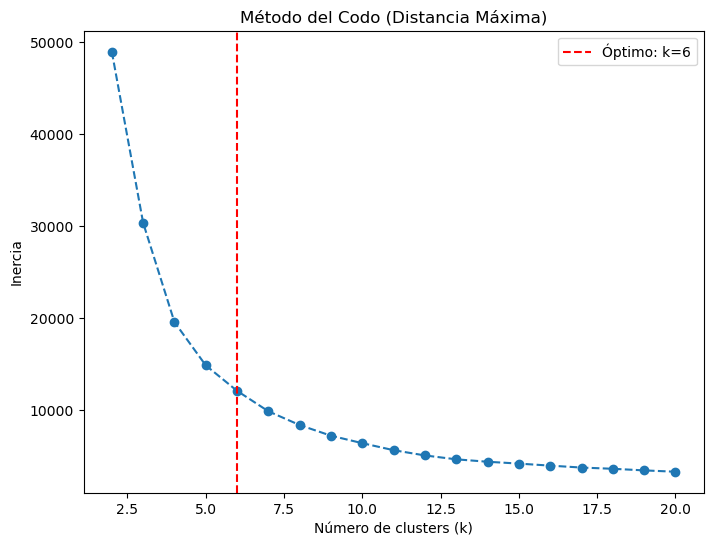

In [6]:
# Gráfico del método del codo
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, marker='o', linestyle='--')
plt.axvline(x=optimal_k_codo, color='red', linestyle='--', label=f'Óptimo: k={optimal_k_codo}')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo (Distancia Máxima)")
plt.legend()
plt.show()

In [7]:
import matplotlib as mpl

# evaluar k entre 2 y 20
k_values = list(range(2, 21))
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# metodo del codo geometrico (distancia segmento recto entre el primer y ultimo punto)
x = np.array(k_values)
y = np.array(inertias)

# Línea recta entre los extremos
point1 = np.array([x[0], y[0]])
point2 = np.array([x[-1], y[-1]])

# Calcula distancia de cada punto a la línea
def perpendicular_distance(pt, line_start, line_end):
    return np.abs(np.cross(line_end - line_start, pt - line_start) / np.linalg.norm(line_end - line_start))

distances = [perpendicular_distance(np.array([x[i], y[i]]), point1, point2) for i in range(len(x))]
optimal_k_codo = x[np.argmax(distances)]

print(f"El número óptimo de clusters es: {optimal_k_codo}")


El número óptimo de clusters es: 6


C:\Users\Infosat\AppData\Local\Temp\ipykernel_24616\1705333943.py:22: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.abs(np.cross(line_end - line_start, pt - line_start) / np.linalg.norm(line_end - line_start))


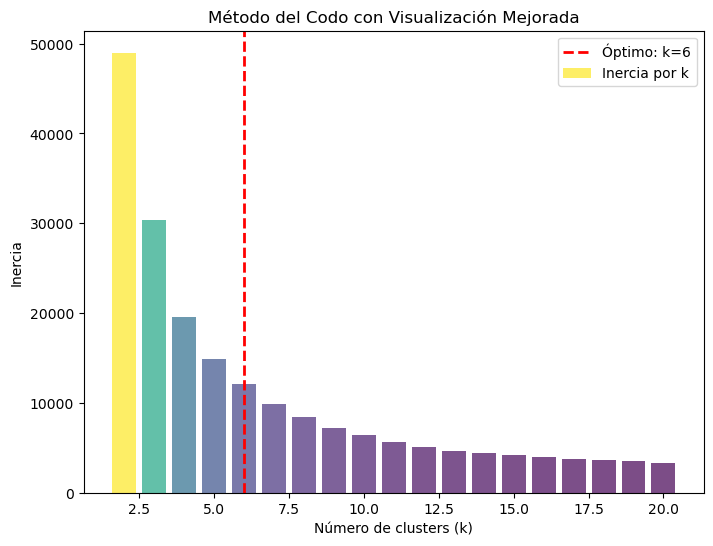

In [8]:
# Gráfico mejorado del método del codo
fig, ax = plt.subplots(figsize=(8, 6))

# Colores progresivos para visualizar mejor la reducción de inercia
norm = mpl.colors.Normalize(vmin=min(inertias), vmax=max(inertias))
colors = [mpl.cm.viridis(norm(val)) for val in inertias]

# Barras para mostrar la caída de inercia
ax.bar(k_values, inertias, color=colors, alpha=0.7, label="Inercia por k")

# Línea roja para indicar el óptimo
ax.axvline(x=optimal_k_codo, color='red', linestyle='--', linewidth=2, label=f'Óptimo: k={optimal_k_codo}')

# Ajustes de etiquetas y título
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
ax.set_title("Método del Codo con Visualización Mejorada")
ax.legend()

plt.show()

**Metodo Silhouette Score**
ejecuta K-Means para valores de k entre 2 y 10, guardando los modelos en kmeans_per_k

Calucla el Silhouette Score para cada modelo, una metrica que evalua que tan bien se agrupan los puntos:

Un valor mas alto indica que lo clusters estan bien definidos

Un valor mas bajo sugiere que los clusters pueden esta solapandose

Determina el k optimo seleccionando el valor donde le Silhouette Score es maximo (optimal_k)

In [9]:
from sklearn.metrics import silhouette_score

# evaluar k entre 2 y 10
k_values = range(2, 10)
kmeans_per_k = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) for k in k_values]

# calcular Silhouette Score para cada modelo
silhouette_scores =[silhouette_score(X, model.labels_) for model in kmeans_per_k]

# determinar el mejor numero de clusters
optimal_k = k_values[np.argmax(silhouette_scores)]

C:\Users\Infosat\AppData\Local\Temp\ipykernel_24616\2337597477.py:3: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "bo-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(k_values, silhouette_scores, "bo-", linestyle="--", label="Silhouette Score")


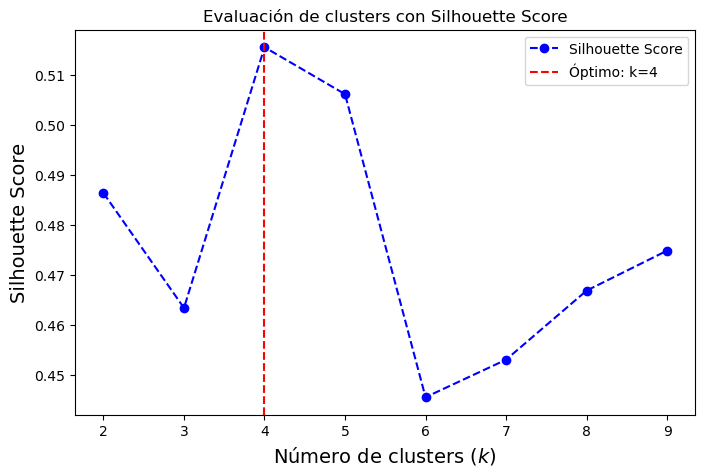

In [10]:
# Gráfico del Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, "bo-", linestyle="--", label="Silhouette Score")
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f"Óptimo: k={optimal_k}")
plt.xlabel("Número de clusters ($k$)", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.title("Evaluación de clusters con Silhouette Score")
plt.legend()
plt.show()

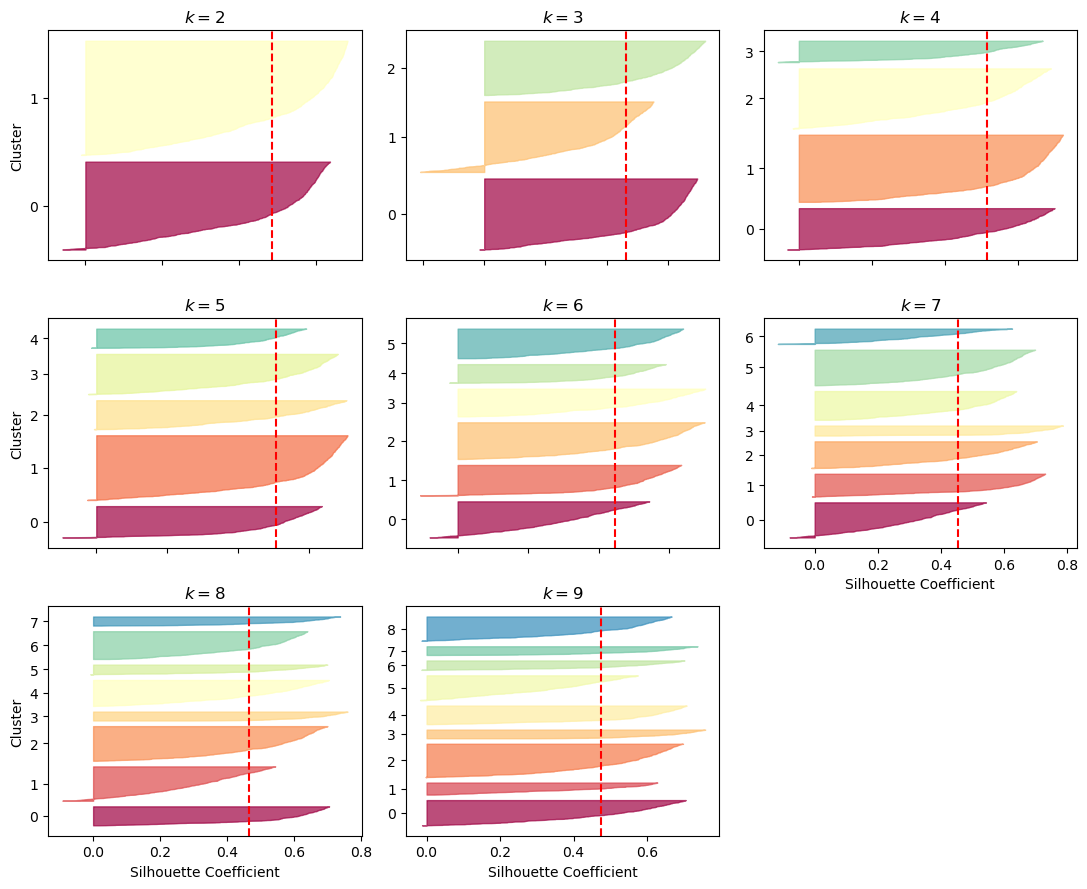

In [11]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

# crear la figura con subgraficos
plt.figure(figsize=(11, 9))

# graficar la distancia de coeficientes de silhouette score para cada k evaluado
for k in k_values:
    plt.subplot(3, 3, k - 1) # ajuste dinamico segun cantidad de k evaluados

    y_pred = kmeans_per_k[k - 2].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    paddig = len(X) // 30
    pos = paddig
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k) # asignar colores a cada cluster
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + paddig

    # Configuración de los ejes
    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (2, 5, 8):
        plt.ylabel("Cluster")

    if k in (7, 8, 9):
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")  # Línea roja para el promedio
    plt.title(f"$k={k}$", fontsize=12)

plt.tight_layout()
plt.show()


**Efectividad del modelo KMeans**

Aplicando K-Means usando los valore optimos de clusters encontrados mediante el metodo del codo y silhouette score, mostrando los resultado en dos graficos comparativos

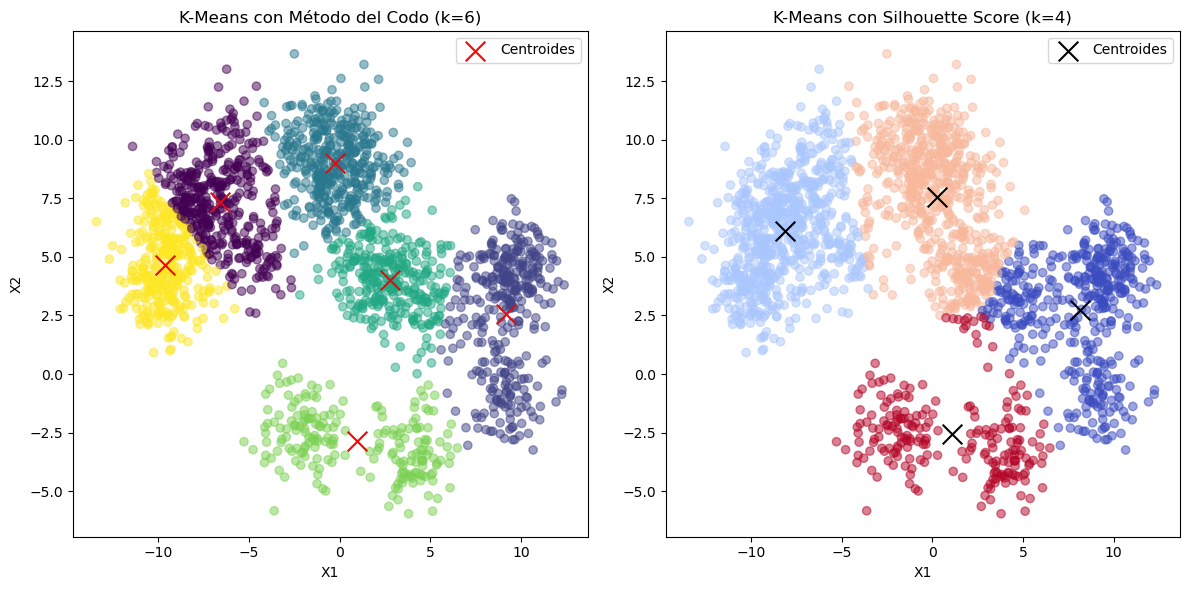

In [12]:
# Aplicar K-Means con los valores obtenidos de cada método
kmeans_codo = KMeans(n_clusters=optimal_k_codo, random_state=42, n_init=10,algorithm="elkan").fit(X)
kmeans_silhouette = KMeans(n_clusters=np.argmax(silhouette_scores) + 2,algorithm="elkan", random_state=42, n_init=10).fit(X)

# Crear las figuras
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico K-Means basado en el método del codo
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_codo.labels_, cmap='viridis', alpha=0.5)
axes[0].scatter(kmeans_codo.cluster_centers_[:, 0], kmeans_codo.cluster_centers_[:, 1],
                c='red', marker='x', s=200, label="Centroides")
axes[0].set_title(f"K-Means con Método del Codo (k={optimal_k_codo})")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].legend()

# Gráfico K-Means basado en Silhouette Score
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans_silhouette.labels_, cmap='coolwarm', alpha=0.5)
axes[1].scatter(kmeans_silhouette.cluster_centers_[:, 0], kmeans_silhouette.cluster_centers_[:, 1],
                c='black', marker='x', s=200, label="Centroides")
axes[1].set_title(f"K-Means con Silhouette Score (k={np.argmax(silhouette_scores) + 2})")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()

# Mostrar gráficos
plt.tight_layout()
plt.show()

# Punto 2: Aprendizaje Semi-supervisado

DataSet: Datos de Voz y Biomédicos de la Enfermedad de Parkinson
Este dataset es fundamental en la investigación biomédica y proviene de un estudio de telemonitorización de pacientes con la enfermedad de Parkinson. Contiene una serie de mediciones de voz y características clínicas registradas de forma remota, lo cual permite un seguimiento detallado de la progresión de la enfermedad.

El objetivo principal de aplicar el Aprendizaje No Supervisado (Clustering) a estos datos es descubrir si existen subgrupos o fenotipos de pacientes que presentan patrones distintos de severidad o progresión de la enfermedad, basándose únicamente en sus características biomédicas. Esto nos ayuda a segmentar la población de estudio de forma objetiva.

Variables Clave para el Clustering (X_scaled):
Edad

Sexo

Tiempo de Prueba

13 Mediciones de Voz (como Jitter, Shimmer, HNR, RPDE, DFA, etc.): Estas son biomarcadores clave que evalúan la estabilidad y el temblor vocal.

PPE: Medida de error de predicción de la voz.

Variables Excluidas (Targets de Predicción):

total_UPDRS: Puntuación total de la Escala Unificada de Clasificación de la Enfermedad de Parkinson.

motor_UPDRS: Puntuación de la subescala motora del UPDRS.

Se importan librerias escenciales para leer el archivo en un DataFrame y separa las features en X(eliminado variables de prediccion)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # Necesario para el Semi-Supervisado
from sklearn.linear_model import LogisticRegression # Necesario para la evaluación
from sklearn.decomposition import PCA # Necesario para las gráficas
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# Sustituimos 'hour.csv' por el nombre del archivo de Parkinson
data = pd.read_csv("parkinsons_updrs.csv")

# --- Definir Features (X) y Target (y) ---
# X: Características para Clustering (Excluyendo IDs, Tiempo y Targets UPDRS)
cols_to_drop_X = ['subject#', 'test_time', 'motor_UPDRS', 'total_UPDRS']
X_features = data.drop(columns=cols_to_drop_X, axis=1)

# y: Target (Puntuación Total UPDRS)
y_target = data["total_UPDRS"] 

print(f"Dataset cargado. Features listos: {X_features.shape}")

Dataset cargado. Features listos: (5875, 18)


In [15]:
# --- Escalado del Dataset Completo (Para Clustering de Exploración) ---
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X_features)

# --- Binarización de la Etiqueta ---
median_updrs = y_target.median()
# Clase binaria: 0 (bajo UPDRS) o 1 (alto UPDRS)
y_class_parkinson = (y_target > median_updrs).astype(int) 

print(f"Dataset escalado y etiqueta binaria creada. Mediana de corte: {median_updrs:.2f}")

Dataset escalado y etiqueta binaria creada. Mediana de corte: 27.58


In [16]:
# --- División de Datos ---
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_class_parkinson, random_state=42, test_size=0.2
)

# --- Re-Escalado (Evitando Fuga de Datos) ---
scaler_semi = StandardScaler()
X_train_scaled = scaler_semi.fit_transform(X_train)
X_test_scaled = scaler_semi.transform(X_test) 


In [17]:
print(X_train_scaled)
print('\n---------------')
print(X_train_scaled.shape)

[[-0.54589801 -0.67896134 -0.11274805 ...  0.08246429  1.43463761
   0.21389789]
 [-0.66063375 -0.67896134 -0.38727575 ...  0.41080485  1.2506967
   0.33894003]
 [ 0.37198792  1.47283791  0.2502181  ...  1.07124297  0.08451972
   0.62137407]
 ...
 [ 0.25725218 -0.67896134 -0.31910444 ...  0.07148994 -0.9461958
  -0.41991765]
 [ 0.14251644 -0.67896134 -0.13670013 ...  0.74685712 -0.76422217
  -0.17026905]
 [-0.20169079 -0.67896134 -0.07405623 ...  0.12023186  0.01510275
   0.23459302]]

---------------
(4700, 18)


In [18]:
print(X_test_scaled)
print('\n---------------')
print(X_test_scaled.shape)

[[ 0.14251644 -0.67896134  0.69241037 ... -0.48197301 -0.12302859
  -0.82979011]
 [-3.29955582  1.47283791 -0.34305652 ... -0.09352072 -0.23966034
   0.13558316]
 [-0.7753695  -0.67896134  0.65740348 ... -0.4882017   1.43337293
   0.18514255]
 ...
 [-1.11957672 -0.67896134  0.26127291 ... -0.57471118  1.37379237
   0.72397834]
 [ 0.0277807  -0.67896134 -0.53651564 ...  0.11202582 -1.038096
  -0.73088918]
 [-0.7753695  -0.67896134  0.32207434 ... -0.41365524  1.93699726
   0.43794988]]

---------------
(1175, 18)


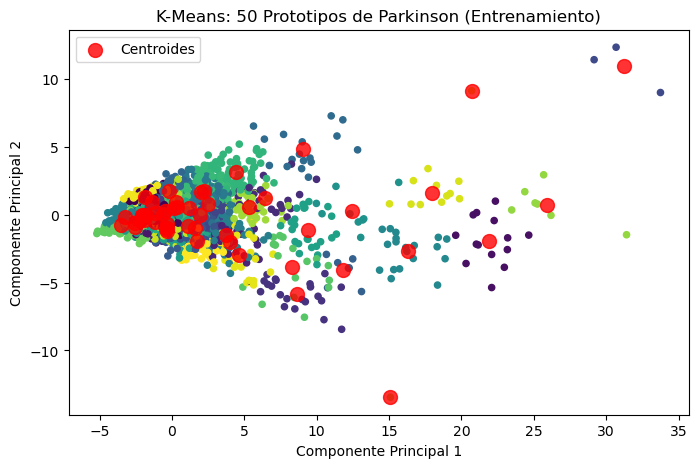

In [ ]:
# --- K-MEANS PARA PROTOTIPOS ---
k = 50 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# --- PCA PARA VISUALIZACIÓN ---
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X_train_scaled)
cluster_centers_reduced = pca.transform(kmeans.cluster_centers_)

# --- GRÁFICA DE DISPERSIÓN (Estilo Notebook) ---
plt.figure(figsize=(8, 5))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=kmeans.labels_, s=20, cmap='viridis')
plt.scatter(cluster_centers_reduced[:, 0], cluster_centers_reduced[:, 1], 
            marker='o', c='red', s=100, alpha=0.8, label='Centroides')
plt.legend()
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title(f'K-Means: 50 Prototipos de Parkinson (Entrenamiento)')
plt.show()

In [ ]:
# --- PROPAGACIÓN DE ETIQUETAS (y_prop) ---
X_dist = kmeans.fit_transform(X_train_scaled) 
idxs = np.argmin(X_dist, axis=0) # Índices de los 50 prototipos
y_repr = y_train.iloc[idxs] # Etiquetas verdaderas de los 50 prototipos

# Creamos las etiquetas auto-asignadas (y_prop)
y_prop = np.empty(len(X_train_scaled), dtype=int)
for i in range(k):
    y_prop[kmeans.labels_ == i] = y_repr.iloc[i] 

# --- ENTRENAMIENTO BASE Y PRECISIÓN PROPAGADA ---
subset_size = 1000
log_reg_prop = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg_prop.fit(X_train_scaled[:subset_size], y_prop[:subset_size])
score_prop = log_reg_prop.score(X_test_scaled, y_test)
print(f"Precisión (Etiquetas Propagadas): {score_prop:.4f}")

# --- ACTIVE LEARNING (CORRECCIÓN DE 10 MUESTRAS) ---
probas = log_reg_prop.predict_proba(X_train_scaled[:subset_size])
labels_conf = np.array([probas[i, ix] for i, ix in enumerate(np.argmax(probas, axis=1))])
sorted_ixs = np.argsort(labels_conf)
active_idxs = sorted_ixs[:10] # 10 muestras con menor confianza

# Corrección Activa
y_true = y_train.values[:subset_size] 
y_train_active = y_prop[:subset_size].copy()
y_train_active[active_idxs] = y_true[active_idxs] # Reemplazo con etiqueta VERDADERA

# --- REENTRENAMIENTO Y EVALUACIÓN FINAL ---
log_reg_active = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg_active.fit(X_train_scaled[:subset_size], y_train_active)
score_active = log_reg_active.score(X_test_scaled, y_test)
print(f"Precisión (Tras 10 Correcciones Activas): {score_active:.4f}")

Precisión (Etiquetas Propagadas): 0.6085
Precisión (Tras 10 Correcciones Activas): 0.6085


# Aprendizaje Activo (Active Learning)

Las variables X_train_scaled, y_prop, y_train, y_test, y log_reg_prop ya existan de los pasos anteriores.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# ASUMIMOS: log_reg_prop ya fue entrenado con las etiquetas propagadas (y_prop)
# y que subset_size = 1000

# --- IDENTIFICACIÓN DE INSEGURIDAD (Active Learning) ---
# Obtenemos las probabilidades de predicción para cada punto en el subset
probas = log_reg_prop.predict_proba(X_train_scaled[:subset_size])

# Calculamos la "Confianza" del modelo para cada predicción
# Cuanto más cerca de 1.0, más seguro está el modelo.
labels_conf = np.array([probas[i, ix] for i, ix in enumerate(np.argmax(probas, axis=1))])

# Ordenamos los índices: buscamos los 10 con la confianza más baja.
sorted_ixs = np.argsort(labels_conf)
active_idxs = sorted_ixs[:10] # Los 10 índices con menor confianza

print(f"Índices de las 10 muestras con menor confianza (Active Learning): {active_idxs}")



Índices de las 10 muestras con menor confianza (Active Learning): [665 890 943 357 314 980 432 514 856 836]


In [ ]:
# --- CORRECCIÓN DE ETIQUETAS Y REENTRENAMIENTO ---
# Copiamos las etiquetas propagadas
y_true = y_train.values[:subset_size] 
y_train_active = y_prop[:subset_size].copy()

# El paso clave del Active Learning: reemplazamos las etiquetas inseguras
# (que eran propagadas) por las etiquetas VERDADERAS (y_true)
y_train_active[active_idxs] = y_true[active_idxs] 

# Reentrenamos el modelo con las 10 etiquetas corregidas
log_reg_active = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg_active.fit(X_train_scaled[:subset_size], y_train_active)

# --- EVALUACIÓN DE LA MEJORA ---
score_prop = log_reg_prop.score(X_test_scaled, y_test)
score_active = log_reg_active.score(X_test_scaled, y_test)

print(f"\nPrecisión ANTES de Active Learning: {score_prop:.4f}")
print(f"Precisión DESPUÉS de 10 correcciones activas: {score_active:.4f}")


Precisión ANTES de Active Learning: 0.6085
Precisión DESPUÉS de 10 correcciones activas: 0.6085
